In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder exists: True


In [4]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["label"].value_counts().sort_index())

Total images: 44000
label
0    12800
1    31200
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

development_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

train_df, validation_df = train_test_split(
    development_df,
    test_size=15 / 85,
    stratify=development_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df)
]:
    print(f"\n{name}: {len(split_df)} images")
    print(split_df["label"].value_counts().sort_index())


Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                10000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    train_df,
    training=True
)

validation_dataset = create_dataset(
    validation_df
)

test_dataset = create_dataset(
    test_df
)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print(
        "Pixel range:",
        float(tf.reduce_min(images)),
        "to",
        float(tf.reduce_max(images))
    )

I0000 00:00:1787588646.901371      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [7]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = {
    0: float(weight_values[0]),
    1: float(weight_values[1])
}

print("Maximum epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Class weights:", class_weights)

Maximum epochs: 30
Patience: 5
Learning rate: 0.0001
Batch size: 32
Class weights: {0: 1.71875, 1: 0.7051282051282052}


In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        0.05,
        0.05
    )
])

xception_base = tf.keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

xception_base.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.xception.preprocess_input(
    x
)

x = xception_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="Xception_Binary"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)

print(
    "Xception frozen:",
    not xception_base.trainable
)

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total parameters: 20863529
Trainable parameters: 2049
Xception frozen: True


Model: "Xception_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/xception_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5839 - loss: 0.6598
Epoch 1: val_loss improved from None to 0.58674, saving model to /kaggle/working/xception_best.keras

Epoch 1: finished saving model to /kaggle/working/xception_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 126s 122ms/step - accuracy: 0.6442 - loss: 0.6239 - val_accuracy: 0.7038 - val_loss: 0.5867 - learning_rate: 1.0000e-04
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7121 - loss: 0.5721
Epoch 2: val_loss improved from 0.58674 to 0.57329, saving model to /kaggle/working/xception_best.keras

Epoch 2: finished saving model to /kaggle/working/xception_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 110s 115ms/step - accuracy: 0.7177 - loss: 0.5646 - val_accuracy: 0.7121 - val_loss: 0.5733 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7317 - loss: 0.5470
Epoch 3: val_loss did not improve from 0.57329
963/963 ━━━━━━━━━━━━━━━━━━━━ 107s 111ms/step - 

In [10]:
history_df = pd.DataFrame(
    history.history
)

history_df.index = range(
    1,
    len(history_df) + 1
)

history_df.index.name = "Epoch"

best_epoch = history_df[
    "val_loss"
].idxmin()

display(
    history_df[
        [
            "loss",
            "accuracy",
            "val_loss",
            "val_accuracy"
        ]
    ].rename(
        columns={
            "loss": "Training Loss",
            "accuracy": "Training Accuracy",
            "val_loss": "Validation Loss",
            "val_accuracy": "Validation Accuracy"
        }
    ).round(4)
)

print("Best epoch:", best_epoch)

,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy
Epoch,,,,
1,0.6239,0.6442,0.5867,0.7038
2,0.5646,0.7177,0.5733,0.7121
3,0.5422,0.7346,0.5942,0.6876
4,0.5349,0.7375,0.6358,0.6518
5,0.5283,0.7400,0.5980,0.6852
6,0.5240,0.7470,0.5714,0.7036
7,0.5215,0.7485,0.5912,0.6859
8,0.5175,0.7514,0.5804,0.6965
9,0.5177,0.7527,0.5866,0.6903


Best epoch: 6


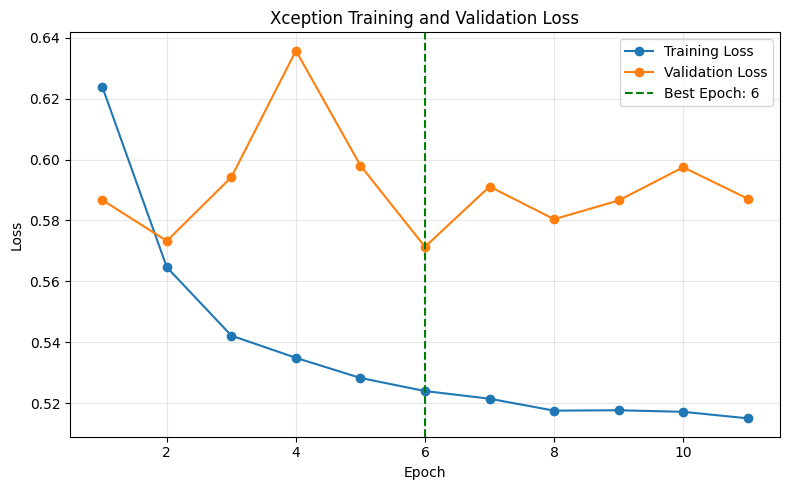

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title(
    "Xception Training and Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

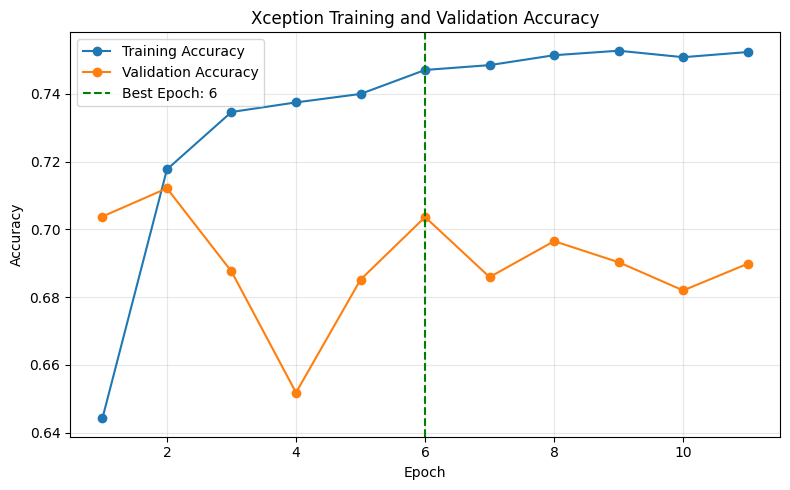

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title(
    "Xception Training and Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

207/207 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.7242 - loss: 0.5520
Test Loss: 0.552
Test Accuracy: 0.7242


In [14]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df[
    "label"
].to_numpy()

print("Test images:", len(true_labels))
print("Predictions:", len(test_predictions))

207/207 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step
Test images: 6600
Predictions: 6600


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_precision = precision_score(
    true_labels,
    test_predictions
)

test_recall = recall_score(
    true_labels,
    test_predictions
)

test_f1 = f1_score(
    true_labels,
    test_predictions
)

test_auc = roc_auc_score(
    true_labels,
    test_probabilities
)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1-score:", round(test_f1, 4))
print("ROC-AUC:", round(test_auc, 4))

Test Loss: 0.552
Accuracy: 0.7242
Precision: 0.9042
Recall: 0.6835
F1-score: 0.7785
ROC-AUC: 0.8374


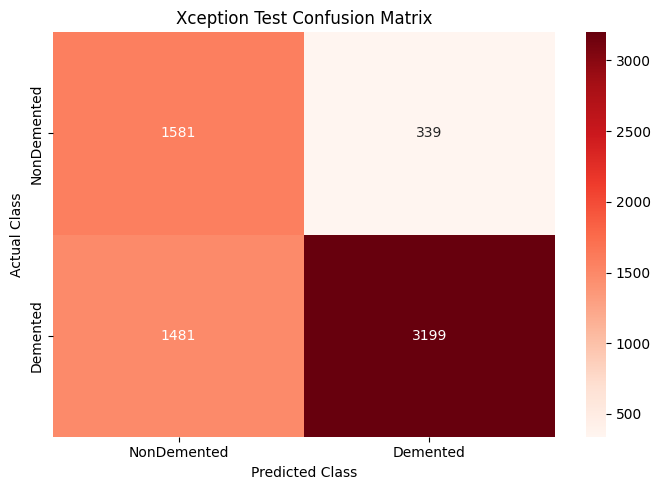

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[
        "NonDemented",
        "Demented"
    ],
    yticklabels=[
        "NonDemented",
        "Demented"
    ]
)

plt.title(
    "Xception Test Confusion Matrix"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

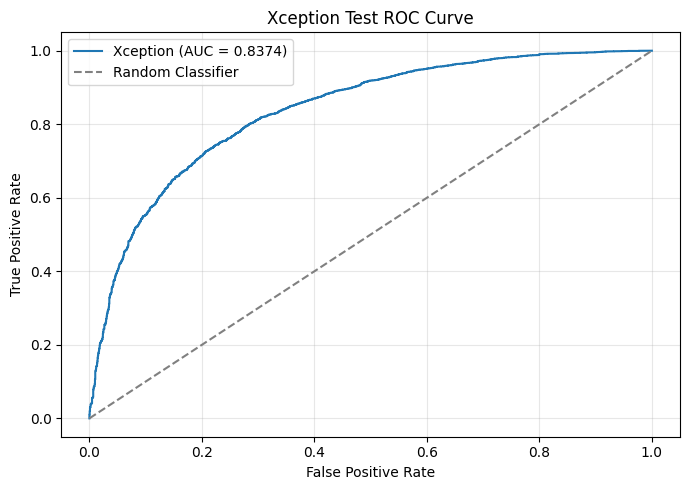

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=(
        f"Xception "
        f"(AUC = {test_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("Xception Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

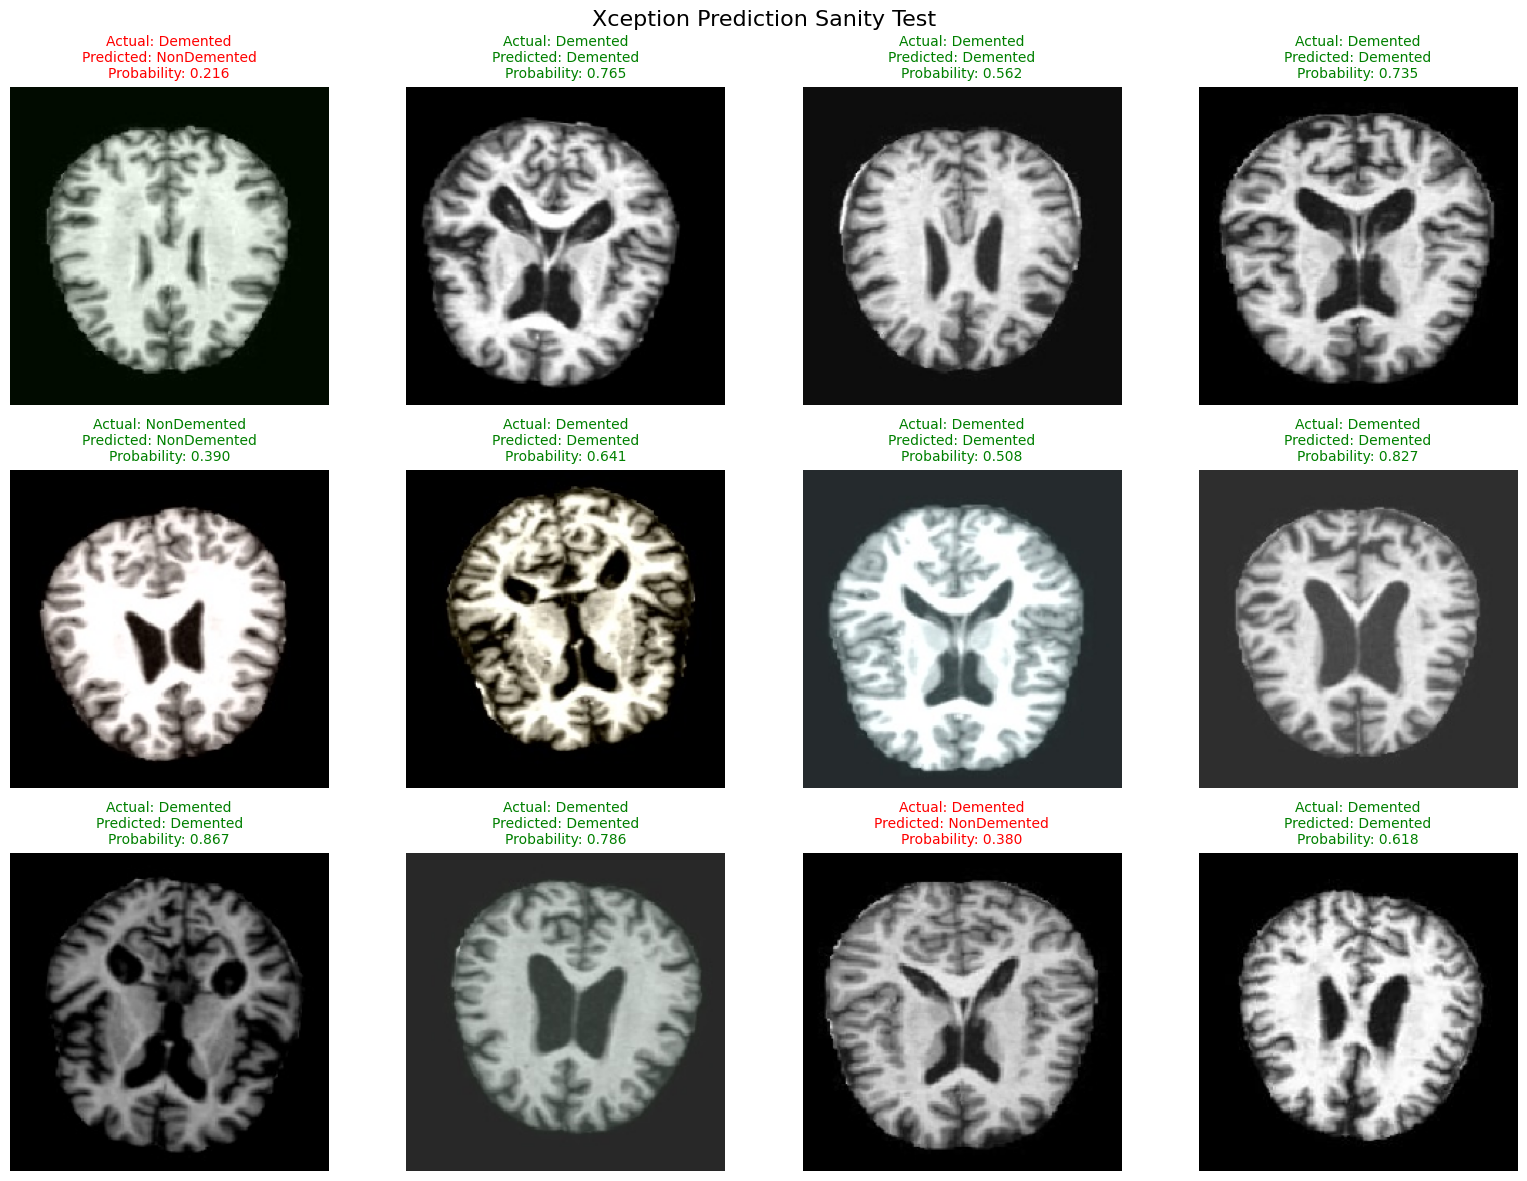

In [18]:
sample_indices = np.random.default_rng(
    SEED
).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(
    sample_indices,
    start=1
):
    image = tf.keras.utils.load_img(
        test_df.iloc[index]["filepath"],
        target_size=IMG_SIZE
    )

    actual = true_labels[index]
    predicted = test_predictions[index]
    probability = test_probabilities[index]

    actual_name = (
        "Demented"
        if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented"
        if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green"
        if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(image)

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Xception Prediction Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
results_df = pd.DataFrame({
    "Model": ["Xception"],
    "Cross-Validation": ["No"],
    "Best Epoch": [best_epoch],
    "Epochs Trained": [len(history_df)],
    "Test Loss": [test_loss],
    "Accuracy": [test_accuracy],
    "Precision": [test_precision],
    "Recall": [test_recall],
    "F1-score": [test_f1],
    "ROC-AUC": [test_auc]
})

history_export_df = (
    history_df
    .reset_index()
)

results_df.to_csv(
    "/kaggle/working/xception_results.csv",
    index=False
)

history_export_df.to_csv(
    "/kaggle/working/xception_training_history.csv",
    index=False
)

display(
    results_df.round(4)
)

print(
    "Xception result files saved."
)

,Model,Cross-Validation,Best Epoch,Epochs Trained,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Xception,No,6,11,0.552,0.7242,0.9042,0.6835,0.7785,0.8374


Xception result files saved.
